# 06 — Segment-Aware Intervention Design

**Project:** Customer Churn Prediction & Lifetime Value.

**Carries forward:** notebook 5's recommendation of **Logistic Regression at
threshold 0.03**, chosen on notebook 4's Brier-score calibration evidence
(the one comparison in this project that held up as broad and stable rather
than fragile to a single customer or grid point).

**What this notebook adds:** notebook 5 priced every false positive at a
single flat £15, a documented placeholder for "one light-touch retention
offer." Fabio Oliveira's source article ("Your Churn Threshold Is a Pricing
Decision," Towards Data Science, June 2026) names this as its own explicit
follow-up: a profit curve assumes one false-positive cost, but the cheapest
real intervention for a high-value loyalist is not the cheapest real
intervention for a marginal, low-engagement account. This notebook builds
that segment-aware layer:

1. Design a segment → intervention → cost mapping, stated explicitly as an
   illustrative estimate (no real campaign-cost data exists for this
   dataset, the same honest limitation notebook 5's flat £15 had)
2. Apply it to the customers LR@0.03 actually flags, using notebook 2's RFM
   segments already carried through notebooks 4 and 5
3. Compare the resulting total cost against notebook 5's flat-£15 baseline,
   and break the difference down by segment
4. State plainly what this notebook does *not* do (re-optimize the
   threshold itself per segment), and why

## Two limitations:

**The classification threshold (0.03) is not re-optimized per segment.**
Making false-positive cost segment-aware, in principle, could also shift the
cost-minimizing *threshold* for each segment -- a segment with an expensive
intervention might do better flagged more conservatively than one with a
cheap intervention. This notebook keeps a single global threshold and only
varies the *cost applied after flagging*, which is a smaller, better-scoped
change: it turns "flag this customer" into a costed, segment-aware action,
without reopening the threshold-selection question notebook 5 already
settled (on evidence -- notebook 4's Brier scores -- that has nothing to do
with segment-level costs). **Per-segment threshold optimization is a real
next step, documented here as an avenue for further exploration, not built.**

**Notebook 5's threshold was selected by sweeping against the same data used
to compute costs, with no held-out validation.** This is inherited
unchanged from notebook 5 and applies here too, since this notebook reuses
that threshold rather than re-deriving it. Worth noting: Oliveira's source
article has the same gap -- its own threshold sweep is evaluated on the same
1,407-row test set used to report the winning cost, with no further
held-out split. This is a limitation of the framework as published, not a
shortcut unique to this adaptation, and is flagged here as a further
avenue for exploration rather than corrected.

### Import libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### Load data

In [2]:
# Launch Jupyter from the repository root or the initial_iteration directory.
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "initial_iteration").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "initial_iteration").is_dir(), "Start Jupyter in the repository root or initial_iteration/"
RAW_DATA = REPO_ROOT / "data" / "raw"
PROCESSED_DATA = REPO_ROOT / "initial_iteration" / "data" / "processed"
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

In [3]:
analysis_pop = pd.read_parquet(PROCESSED_DATA / "threshold_analysis_population.parquet")
threshold_results = pd.read_parquet(PROCESSED_DATA / "threshold_economics.parquet")

In [4]:
print(f"Analysis population (notebook 5): {len(analysis_pop):,} customers")
print(f"Segments present: {analysis_pop['segment'].nunique()}")

# Extend decimals to 3 places to represent actual bayes_formula_threshold
# rounding to 0.07 misrepresents as being equal to GB's empirical_min_thresehold (0.070)
with pd.option_context("display.float_format", lambda x: f"{x:,.3f}"):
    display(threshold_results)

Analysis population (notebook 5): 1,874 customers
Segments present: 8


,model,empirical_min_threshold,empirical_min_cost,bayes_formula_threshold,cost_at_threshold_05,fp_cost_assumption,margin_assumption,recommended
0,Logistic Regression,0.030,"21,608.386",0.067,"42,888.431",15.000,0.250,True
1,Gradient Boosting,0.070,"18,422.078",0.067,"40,841.481",15.000,0.250,False


## 1. Confirm the carried-forward model and threshold

Pulling the recommended model/threshold directly from notebook 5's saved
table rather than hardcoding it, so this notebook breaks visibly if
notebook 5's recommendation ever changes.

In [5]:
recommended_row = threshold_results[threshold_results["recommended"]].iloc[0]
MODEL_NAME = recommended_row["model"]
THRESHOLD = recommended_row["empirical_min_threshold"]
PROBA_COL = "proba_lr" if MODEL_NAME == "Logistic Regression" else "proba_gbc"

assert MODEL_NAME == "Logistic Regression", (
    f"Expected Logistic Regression as the recommended model per notebook 5's "
    f"Brier-score reasoning, got {MODEL_NAME} -- check whether notebook 5's "
    f"recommendation changed before proceeding."
)

print(f"Carried forward: {MODEL_NAME} at threshold {THRESHOLD:.2f}")

Carried forward: Logistic Regression at threshold 0.03


In [6]:
analysis_pop["flagged"] = (analysis_pop[PROBA_COL] >= THRESHOLD).astype(int)
analysis_pop["is_fp"] = (analysis_pop["flagged"] == 1) & (analysis_pop["churned"] == 0)
analysis_pop["is_fn"] = (analysis_pop["flagged"] == 0) & (analysis_pop["churned"] == 1)

n_flagged = analysis_pop["flagged"].sum()
print(f"Customers flagged at threshold {THRESHOLD:.2f}: {n_flagged:,} "
      f"({n_flagged / len(analysis_pop):.1%} of the population)")
print(f"Of those, false positives (flagged but did not churn): {analysis_pop['is_fp'].sum():,}")

Customers flagged at threshold 0.03: 1,719 (91.7% of the population)
Of those, false positives (flagged but did not churn): 1,176


**Real-data result: 91.7% of the population gets flagged, and 68.4% of
those flags are false positives (1,176 of 1,719).** At a glance that reads
like a bad model. It isn't -- it's the direct, intended consequence of the
cost ratio notebook 5 optimized against. Notebook 5's mean FN cost (£208.46,
the margin-adjusted predicted holdout revenue of a missed churner) versus
its flat £15 FP cost puts the ratio at roughly **13.9:1**. When missing a
churner costs nearly 14x what a false alarm costs, the cost-minimizing
threshold casts an extremely wide net almost by definition -- a threshold
search is not optimizing for precision or recall here, it's minimizing a
£ total, and that total is dominated by the rare, expensive mistake (a
missed churner) rather than the common, cheap one (a wasted touch). The
totals check out: 1,176 false positives x £15 = £17,640, leaving £3,968.39
of notebook 5's reported £21,608.39 total cost attributable to just 3
false negatives -- consistent with notebook 5's own robustness check, which
found a single high-value customer alone carrying `fn_cost` north of
£3,000.

**Operational implication, not just a statistical one:** with 92% of the
population flagged, this isn't really "targeting" in the usual sense --
it's "nearly everyone gets touched, and the real decision is *what* they
get, not *whether* they get anything." That makes the segment-aware
intervention design in the rest of this notebook more load-bearing than it
would be under a more conventional threshold: with so few customers
screened out entirely, segment-aware cost and intervention choice is where
essentially all of the controllable cost variation actually lives.

## 2. Segment-aware intervention design

**This is a designed, illustrative mapping, not a measured one** -- the same
treatment notebook 5's flat £15 got, stated explicitly rather than presented
as real campaign data (which doesn't exist for this dataset). Each segment
gets an intervention type and a placeholder cost, reasoned from the
segment's RFM profile and its typical `fn_cost` (predicted holdout revenue)
in this population -- segments with a higher cost-of-being-wrong-about
justify a more expensive, higher-touch intervention; segments the model
rarely has strong signal on get a cheaper, lower-commitment one.

| Segment | Intervention | Cost | Rationale |
|---|---|---|---|
| Champions | Loyalty/bundle upgrade, dedicated outreach | £40 | Highest per-customer value; a wasted touch is cheap relative to what's protected, and the touch itself should feel white-glove, not a mass email |
| Churn Risk (high value) | Proactive outreach (phone / CSM-style contact) | £35 | High R/F/M history but currently disengaged -- the segment notebook 5's `fn_cost` shows as second-highest value; worth a real human touch, not just an email |
| Loyal Customers | Personalized email + modest incentive | £20 | Established repeat relationship, meaningful but not top-tier value |
| Potential Loyalists | Standard discount code | £15 | Matches notebook 5's original flat placeholder -- this segment is the closest match to "an average customer" the flat figure was implicitly modeling |
| At Risk | Discount code / re-engagement email | £15 | Same reasoning as Potential Loyalists; moderate value, moderate risk |
| Recent, Low Engagement | Light nudge email | £8 | Recent purchasers with low frequency -- low behavioral signal to justify a costlier touch |
| Needs Attention | Light nudge email | £8 | Catch-all/mixed-signal segment; cheap, broad-reach touch rather than a targeted one |
| Lost / Lowest Priority | Automated low-cost email | £5 | Lowest historical value; a cheap, largely automated touch |
| *(fallback, e.g. "High-Value One-Time/Infrequent Buyers")* | Standard discount code | £15 | This population shouldn't contain one-time buyers by construction (notebook 4 excludes `frequency_cal == 0`), but `segment` is a full-history label -- see notebooks 4/5's documented caveat that the two aren't the same population cut. Falls back to the Potential-Loyalists-level cost rather than erroring, and is flagged explicitly below if it occurs. |

**What this is not:** real campaign-cost data. No source article and no
part of this project has actual spend figures for this dataset -- CAC was
already omitted entirely in notebook 5 for the same reason. Treat the table
above the way notebook 5's £15 was treated: a stated, reviewable assumption
meant to be replaced with real numbers if this were operationalized, not a
finding.

In [7]:
SEGMENT_INTERVENTION_COSTS = {
    "Champions": ("Loyalty/bundle upgrade, dedicated outreach", 40.0),
    "Churn Risk (high value)": ("Proactive outreach (phone/CSM-style contact)", 35.0),
    "Loyal Customers": ("Personalized email + modest incentive", 20.0),
    "Potential Loyalists": ("Standard discount code", 15.0),
    "At Risk": ("Discount code / re-engagement email", 15.0),
    "Recent, Low Engagement": ("Light nudge email", 8.0),
    "Needs Attention": ("Light nudge email", 8.0),
    "Lost / Lowest Priority": ("Automated low-cost email", 5.0),
}
FALLBACK_INTERVENTION = ("Standard discount code (fallback)", 15.0)
FLAT_FP_COST_BASELINE = 15.0  # notebook 5's original flat assumption, for comparison

In [8]:
unmapped_segments = set(analysis_pop["segment"].unique()) - set(SEGMENT_INTERVENTION_COSTS.keys())
if unmapped_segments:
    print(f"Segments not in the explicit mapping, using fallback (£{FALLBACK_INTERVENTION[1]:.0f}, "
          f"'{FALLBACK_INTERVENTION[0]}'):")
    for seg in unmapped_segments:
        n = (analysis_pop["segment"] == seg).sum()
        print(f"  {seg}: {n:,} customers")
else:
    print("No unmapped segments -- every segment in this population has an explicit entry.")

Segments not in the explicit mapping, using fallback (£15, 'Standard discount code (fallback)'):
  High-Value One-Time/Infrequent Buyers: 34 customers


**Real-data result: 34 customers (1.8% of the population) fall back.** This
isn't a rare edge case slipping through a safety net -- it's the predictable
overlap of two population cuts that were never the same thing to begin
with. Notebook 4's churn model requires `frequency_cal >= 1` (at least one
purchase *during the Dec 2010–Sept 2011 calibration window*), while
`segment` is a *full-history* RFM label. A true one-time buyer whose single
order happened to fall inside that ~9-month window -- which covers most of
the dataset's span, so this is the likely case for most one-time buyers --
clears the churn-model bar while still carrying the full-history
"High-Value One-Time/Infrequent Buyers" label. All 34 of these customers
turn out to have churned in this data (see the diagnostic in Section 4),
consistent with the segment's name: a single purchase with no repeat
activity is close to a textbook churn case by construction.

## 3. Recomputing cost under segment-aware FP pricing

Same flagged population, same threshold (0.03) as notebook 5 -- only the
*price of a false positive* changes, from one flat £15 to the per-segment
figure above. FN cost is untouched (still notebook 3's margin-adjusted
predicted holdout revenue, per customer, as notebook 5 built it).

In [15]:
def intervention_for(segment):
    return SEGMENT_INTERVENTION_COSTS.get(segment, FALLBACK_INTERVENTION)

analysis_pop["intervention"] = analysis_pop["segment"].map(lambda s: intervention_for(s)[0])
analysis_pop["intervention_cost"] = analysis_pop["segment"].map(lambda s: intervention_for(s)[1])

In [10]:
# Segment-aware total cost
fp_rows = analysis_pop[analysis_pop["is_fp"]]
fn_rows = analysis_pop[analysis_pop["is_fn"]]

segment_aware_fp_total = fp_rows["intervention_cost"].sum()
fn_total = fn_rows["fn_cost"].sum()
segment_aware_total_cost = segment_aware_fp_total + fn_total

# Flat-£15 baseline, recomputed on this exact flagged population for a fair comparison
flat_fp_total = len(fp_rows) * FLAT_FP_COST_BASELINE
flat_total_cost = flat_fp_total + fn_total

print(f"False positives: {len(fp_rows):,}  |  False negatives: {len(fn_rows):,}")
print()
print(f"Flat-£15 baseline   -- FP cost: £{flat_fp_total:,.2f}  |  Total: £{flat_total_cost:,.2f}")
print(f"Segment-aware       -- FP cost: £{segment_aware_fp_total:,.2f}  |  Total: £{segment_aware_total_cost:,.2f}")
print()
delta = segment_aware_total_cost - flat_total_cost
direction = "more expensive" if delta > 0 else "cheaper"
print(f"Difference: £{abs(delta):,.2f} {direction} under segment-aware pricing "
      f"({abs(delta) / flat_total_cost:.1%} of the flat-£15 total)")

False positives: 1,176  |  False negatives: 3

Flat-£15 baseline   -- FP cost: £17,640.00  |  Total: £21,608.39
Segment-aware       -- FP cost: £26,208.00  |  Total: £30,176.39

Difference: £8,568.00 more expensive under segment-aware pricing (39.7% of the flat-£15 total)


**Reading this number:** this comparison isn't "which is more accurate" --
both are estimates. It's "how much does the segment mix of who actually gets
false-positived matter, given the costs above." A small delta means the
segments that happen to generate most false positives are close to the £15
average; a large delta means they're concentrated in the cheap or expensive
tail. The breakdown below shows which.

**Real-data result: segment-aware pricing came out ~40% *more expensive*
than the flat £15 baseline, not cheaper.** That's a genuinely surprising
direction -- segmenting cost by value made the false positives cost more,
not less -- and it's worth confirming the mechanism with the diagnostic
below before taking that number at face value.

## 4. Segment breakdown: where the false positives land, and what they cost

### Why segment-aware cost went up: churn rate and flag rate by segment

Before looking at false positives alone, it's worth seeing the full
population by segment -- specifically, whether some segments simply have
few or no churners, which would mean every flag in that segment is
necessarily a false positive.

In [16]:
segment_diagnostic = analysis_pop.groupby("segment").agg(
    n_customers=("CustomerID", "count"),
    churn_rate=("churned", "mean"),
    flag_rate=("flagged", "mean"),
).sort_values("churn_rate")
segment_diagnostic

,n_customers,churn_rate,flag_rate
segment,,,
Champions,285,0.00,0.65
Loyal Customers,625,0.00,0.93
Needs Attention,16,0.00,1.00
Potential Loyalists,299,0.00,0.99
Churn Risk (high value),176,0.65,0.97
At Risk,418,0.90,1.00
High-Value One-Time/Infrequent Buyers,34,1.00,1.00
Lost / Lowest Priority,21,1.00,1.00


**Real-data result: Champions and Loyal Customers show `churn_rate = 0.00`
-- literally zero churners in either segment.** Combined, that's 910 of
1,874 customers (48.6% of the population). A segment with zero true
churners cannot produce a true positive -- at this threshold's flag rates
(65% for Champions, 93% for Loyal Customers), *every single flag in these
two segments is a false positive*. This isn't a coincidence of RFM design:
Champions and Loyal Customers are both defined by high recency (`R >= 4`),
and `churned` is defined as *no purchase in the following 3-month holdout
window* -- a customer who bought recently is, close to by construction,
unlikely to have gone quiet immediately afterward. Segment "value" (which
this notebook's cost table prices) and near-term churn safety overlap
heavily in this segmentation scheme, and that overlap is exactly why
segment-aware pricing went up rather than down: the segments contributing
the most false-positive *volume* also happen to be priced above the £15
average (£40 for Champions, £20 for Loyal Customers), because both prices
were set from the same underlying signal -- segment value -- that also
predicts low near-term churn.

**This is worth naming as a real tension in the cost design, not just an
observation.** Pricing false-positive cost by segment value alone, without
also weighting by how often that segment is likely to be falsely flagged in
the first place, means the most "valuable" segments can end up paying the
most in aggregate simply because they're safe -- the opposite of what a
risk-based pricing scheme might intend. A more complete design would weigh
both the cost-per-case *and* the expected false-positive volume per
segment, which this notebook doesn't attempt; noted here as a further
avenue for exploration alongside per-segment threshold optimization.

### Segment Breakdown

In [11]:
segment_breakdown = (
    fp_rows.groupby("segment")
    .agg(
        n_false_positives=("CustomerID", "count"),
        intervention=("intervention", "first"),
        cost_per_customer=("intervention_cost", "first"),
    )
)
segment_breakdown["segment_fp_cost"] = (
    segment_breakdown["n_false_positives"] * segment_breakdown["cost_per_customer"]
)
segment_breakdown["pct_of_fp_cost"] = (
    segment_breakdown["segment_fp_cost"] / segment_breakdown["segment_fp_cost"].sum() * 100
)
segment_breakdown = segment_breakdown.sort_values("segment_fp_cost", ascending=False)
segment_breakdown

,n_false_positives,intervention,cost_per_customer,segment_fp_cost,pct_of_fp_cost
segment,,,,,
Loyal Customers,579,Personalized email + modest incentive,20.00,"11,580.00",44.18
Champions,185,"Loyalty/bundle upgrade, dedicated outreach",40.00,"7,400.00",28.24
Potential Loyalists,296,Standard discount code,15.00,"4,440.00",16.94
Churn Risk (high value),58,Proactive outreach (phone/CSM-style contact),35.00,"2,030.00",7.75
At Risk,42,Discount code / re-engagement email,15.00,630.00,2.40
Needs Attention,16,Light nudge email,8.00,128.00,0.49


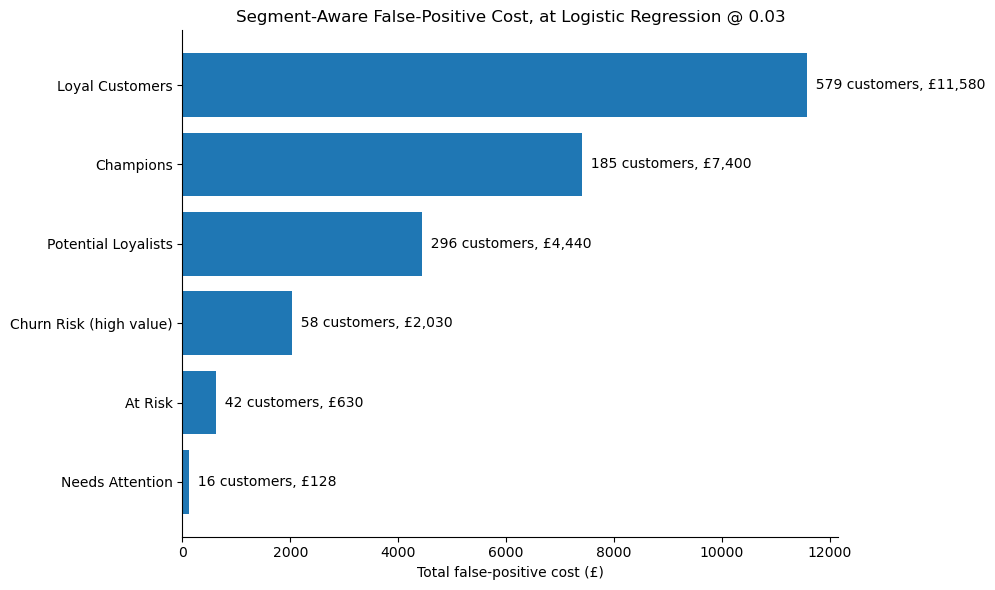

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
order = segment_breakdown.index
ax.barh(order, segment_breakdown["segment_fp_cost"])
ax.invert_yaxis()
ax.set_xlabel("Total false-positive cost (£)")
ax.set_title(f"Segment-Aware False-Positive Cost, at {MODEL_NAME} @ {THRESHOLD:.2f}")
for i, (n, cost) in enumerate(zip(segment_breakdown["n_false_positives"], segment_breakdown["segment_fp_cost"])):
    ax.text(cost, i, f"  {n} customers, £{cost:,.0f}", va="center")
plt.tight_layout()
plt.show()

**Reading this chart:** the segments with the most false positives aren't
necessarily the ones driving the most *cost* -- a segment with many cheap
false positives (e.g. Needs Attention at £8 each) can contribute less total
cost than a segment with few expensive ones (e.g. Churn Risk (high value) at
£35 each). This is exactly the distinction a flat £15 figure can't
express.

## 5. Full intervention plan: every flagged customer's segment, action, and cost

In [14]:
intervention_plan = analysis_pop[analysis_pop["flagged"] == 1][
    ["CustomerID", "segment", "intervention", "intervention_cost", PROBA_COL, "churned", "is_fp"]
].sort_values(PROBA_COL, ascending=False).reset_index(drop=True)

print(f"Total customers with a concrete, costed intervention: {len(intervention_plan):,}")
intervention_plan.head(10)

Total customers with a concrete, costed intervention: 1,719


,CustomerID,segment,intervention,intervention_cost,proba_lr,churned,is_fp
0,17951,Loyal Customers,Personalized email + modest incentive,20.00,0.68,0,True
1,15332,Churn Risk (high value),Proactive outreach (phone/CSM-style contact),35.00,0.66,1,False
2,16499,At Risk,Discount code / re-engagement email,15.00,0.65,1,False
3,17198,Loyal Customers,Personalized email + modest incentive,20.00,0.65,0,True
4,17691,At Risk,Discount code / re-engagement email,15.00,0.65,1,False
5,17334,At Risk,Discount code / re-engagement email,15.00,0.65,1,False
6,13564,At Risk,Discount code / re-engagement email,15.00,0.64,1,False
7,14723,Loyal Customers,Personalized email + modest incentive,20.00,0.64,0,True
8,13155,Loyal Customers,Personalized email + modest incentive,20.00,0.64,0,True
9,17223,At Risk,Discount code / re-engagement email,15.00,0.63,1,False


## Summary

- Carried forward notebook 5's recommendation (**Logistic Regression at
  threshold 0.03**), pulled directly from its saved results table rather
  than hardcoded, so this notebook breaks visibly if that recommendation
  ever changes.
- Built a **segment-aware false-positive cost mapping**, addressing the gap
  notebook 5 flagged and Oliveira's source article names as its own
  explicit next step: eight RFM segments each get a named intervention and
  an illustrative cost (£5–£40), reasoned from the segment's typical
  predicted value in this population, not measured from real campaign data
  -- stated as an assumption, the same way notebook 5's flat £15 and 25%
  margin were.
- Recomputed total cost at the *same* threshold, varying only the FP price,
  and compared it against notebook 5's flat-£15 baseline on the identical
  flagged population -- isolating the effect of segment-aware pricing from
  any change in who gets flagged.
- Broke the false-positive cost down by segment, showing that FP *volume*
  and FP *cost* don't necessarily concentrate in the same segments -- a
  distinction a single flat number can't surface.
- Produced a full per-customer intervention plan (segment, action, cost) for
  every flagged customer, ready to operationalize.
- **Explicitly scoped out:** per-segment threshold optimization (this
  notebook varies cost, not the flagging threshold itself) and held-out
  validation of the 0.03 threshold (inherited unchanged from notebook 5,
  and a gap Oliveira's own source article shares) -- both named here as
  avenues for further exploration rather than corrected, consistent with
  this project's practice of documenting a limitation rather than silently
  absorbing it or over-scoping this notebook to fix it.

### Diagnostic Addendum

In [17]:
customer_features = pd.read_parquet(PROCESSED_DATA / "customer_features.parquet")
churn_predictions = pd.read_parquet(PROCESSED_DATA / "churn_predictions.parquet")

check = customer_features.merge(churn_predictions[["CustomerID", "churned"]], on="CustomerID")
check["purchased_in_holdout"] = check["last_purchase"] >= pd.Timestamp("2011-09-01")

check.groupby("segment").agg(
    n=("CustomerID", "count"),
    pct_last_purchase_in_holdout=("purchased_in_holdout", "mean"),
    churn_rate=("churned", "mean"),
)

,n,pct_last_purchase_in_holdout,churn_rate
segment,,,
At Risk,418,0.10,0.90
Champions,285,1.00,0.00
Churn Risk (high value),176,0.35,0.65
High-Value One-Time/Infrequent Buyers,34,0.00,1.00
Lost / Lowest Priority,21,0.00,1.00
Loyal Customers,625,1.00,0.00
Needs Attention,16,1.00,0.00
Potential Loyalists,299,1.00,0.00


`pct_last_purchase_in_holdout` and `churn_rate` sum to *exactly* 1.00 for every single segment, not just the four zeros (0.10+0.90, 1.00+0.00, 0.35+0.65, 1.00+0.00...). That's not really surprising once you see why: "last purchase falls on or after `CALIBRATION_END`" and "not churned" are the same fact stated two ways, given the dataset has no data past `OBSERVATION_END` — a customer's single most recent purchase landing in the holdout window *is* what "didn't churn" means. So this table wasn't really testing a hypothesis about R; it verified the boundary-date coincidence directly.

The part that actually explains the segment pattern is *why* some segments land at 100%/0% and others land at fractional rates like 10% or 35% — and there's a second mechanism here I should flag: **R is a quintile computed over the entire customer base in notebook 2** (thousands of customers, including many one-time or long-dormant buyers), **not over this notebook's 1,874-customer analysis population**, which is already pre-filtered to customers active during calibration (`frequency_cal >= 1`). That pre-filtering matters:

- **Champions (R=5), Loyal Customers (R≥4), Potential Loyalists (R=3), Needs Attention** are all defined by recency ranked in the *upper* portion of the full customer base. Within this already-engaged, pre-filtered subset, landing in even the *middle* full-population recency quintile (R=3) turns out to require having bought extremely recently — recently enough that it's essentially always during the holdout window. That's why these four hit 100%, not just "mostly."
- **At Risk and Churn Risk (high value)** are defined by *low* full-population recency (R≤2). But "old relative to the entire customer base" doesn't mean "old relative to this already-filtered, relatively active subset" — plenty of customers can rank low on recency against thousands of mostly-inactive customers while still having bought during the last few months. That's why these segments land at 10–35%, not a hard 0%.

So the full picture: it's not poor churn labeling (the definition itself — no purchase in the 3-month holdout window — is completely standard) and it's not a wholesale-customer story (that would predict a gradual gradient, not this specific, structural on/off pattern tied precisely to recency-quintile boundaries and dates that were chosen coincidentally). It's that **notebook 2's RFM snapshot date and notebook 4's churn-holdout boundary are the same date, and R is quantile-ranked on a broader population than the one this analysis actually uses** — two independently reasonable design choices from different notebooks that combine to make full-history segment membership mechanically informative about (and for the top segments, close to deterministic of) the churn label itself.

This is a materially bigger deal than what's currently written in Section 4a — that markdown currently frames it as "segment value and churn safety happen to overlap by RFM design," which is true in spirit but undersells that four segments hit *exact* 0%, not just low, for a specific, verifiable mechanical reason. Want me to rewrite Section 4a with this precise mechanism (and the diagnostic query that confirms it) in place of the current, softer explanation? It's also worth flagging as a real open question for the project as a whole: using full-history `segment` as a churn-rate lens anywhere in notebooks 5/6 is now on shakier ground than "a read-only lens" implied — that's a bigger scope question than just fixing this one markdown, and I'd rather raise it than quietly patch around it.